In [1]:
# load packages needed for decision tree and random forest regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# load clean data in — baseline feature set 
CRMLSSold_cleaned = pd.read_csv('../data/cleaned_CRMLSSOLD_baseline.csv')
print(CRMLSSold_cleaned.info())
CRMLSSold_cleaned.head()

<class 'pandas.DataFrame'>
RangeIndex: 79306 entries, 0 to 79305
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CloseDate              79306 non-null  str    
 1   ClosePrice             79306 non-null  float64
 2   LivingArea             79306 non-null  float64
 3   BedroomsTotal          79306 non-null  int64  
 4   BathroomsTotalInteger  79306 non-null  int64  
 5   YearBuilt              79306 non-null  int64  
 6   GarageSpaces           76469 non-null  float64
 7   LotSizeSquareFeet      77911 non-null  float64
 8   CountyOrParish         79306 non-null  str    
 9   Latitude               79306 non-null  float64
 10  Longitude              79306 non-null  float64
 11  PoolPrivateYN          79306 non-null  str    
 12  ViewYN                 79306 non-null  str    
 13  FireplaceYN            79306 non-null  str    
 14  NewConstructionYN      79306 non-null  str    
 15  HasAssociatio

,CloseDate,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,GarageSpaces,LotSizeSquareFeet,CountyOrParish,Latitude,Longitude,PoolPrivateYN,ViewYN,FireplaceYN,NewConstructionYN,HasAssociationFee
0,2025-11-30,1250000.0,1027.0,3,2,1961,2.0,5913.0,Orange,33.676050,-117.995210,False,False,False,False,False
1,2025-11-20,2299995.0,1129.0,3,1,1949,2.0,18432.0,Santa Clara,37.260693,-121.934121,Unknown,False,True,False,Unknown
2,2025-11-26,810000.0,1619.0,4,3,1978,2.0,5300.0,San Diego,32.564997,-117.064393,False,False,True,Unknown,False
3,2025-11-17,925000.0,2872.0,5,3,2000,3.0,5272.0,San Diego,32.575778,-117.024433,False,False,True,Unknown,True
4,2025-11-25,1300000.0,1727.0,3,2,1950,3.0,10500.0,San Luis Obispo,35.553064,-120.708510,False,False,True,False,False


### train/test function

In [3]:
# Same time-based train/test split as 03_baseline_model.ipynb
def make_train_test_split(df, feature_cols, training_months=None):
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])
    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    test_month  = df['CloseMonth'].max()
    train_start = test_month - training_months if training_months else df['CloseMonth'].min()

    train = df[(df['CloseMonth'] >= train_start) & (df['CloseMonth'] < test_month)].copy()
    test  = df[df['CloseMonth'] == test_month].copy()

    X_train = train[feature_cols]
    y_train = train['ClosePrice']
    X_test  = test[feature_cols]
    y_test  = test['ClosePrice']

    print(f"Test month:  {test_month}")
    print(f"Train range: {train['CloseMonth'].min()} to {train['CloseMonth'].max()}  ({train['CloseMonth'].nunique()} months)")
    print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

    return X_train, y_train, X_test, y_test

In [4]:
# Features and preprocessing — trees don't need scaling or log transforms,
# but we keep log(ClosePrice) so R^2 is directly comparable to the baseline model
feature_cols = [col for col in CRMLSSold_cleaned.columns if col != 'ClosePrice']
categorical_cols = ['PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'NewConstructionYN',
                    'HasAssociationFee', 'CountyOrParish']
numeric_cols = ['LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
                'YearBuilt', 'GarageSpaces', 'Latitude', 'Longitude']

CRMLSSold_cleaned['ClosePrice'] = np.log(CRMLSSold_cleaned['ClosePrice'])

# numeric columns only need median imputation (GarageSpaces, LotSizeSquareFeet) — no scaling needed for trees
preprocessor = ColumnTransformer([
    ('impute', SimpleImputer(strategy='median'), numeric_cols),
    ('encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train, y_train, X_test, y_test = make_train_test_split(
    CRMLSSold_cleaned, feature_cols, training_months=None
)

Test month:  2026-06
Train range: 2025-11 to 2026-05  (7 months)
X_train: (67179, 15)  |  X_test: (12127, 15)


### Fit model and model comparison plot/ Post Model Plots

In [5]:
# Fit Decision Tree and Random Forest with default hyperparameters,
# evaluate on both train and the held-out test month to check for overfitting.
model_classes = {'DecisionTree': DecisionTreeRegressor, 'RandomForest': RandomForestRegressor}

results = {}
for name, model_class in model_classes.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_class(random_state=42))
    ])
    pipeline.fit(X_train, y_train)

    train_preds = pipeline.predict(X_train)
    train_r2 = r2_score(y_train, train_preds)
    train_rmse = mean_squared_error(y_train, train_preds) ** 0.5

    preds = pipeline.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    results[name] = {
        'pipeline': pipeline,
        'train_r2': train_r2, 'train_rmse': train_rmse,
        'r2': r2, 'rmse': rmse,
    }
    print(f"{name}")
    print(f"  Train R^2:              {train_r2:.4f}")
    print(f"  Train RMSE (log price): {train_rmse:.4f}")
    print(f"  Test R^2:               {r2:.4f}")
    print(f"  Test RMSE (log price):  {rmse:.4f}")
    print(f"  R^2 gap (train - test): {train_r2 - r2:.4f}\n")

DecisionTree
  Train R^2:              0.9999
  Train RMSE (log price): 0.0066
  Test R^2:               0.8334
  Test RMSE (log price):  0.2475
  R^2 gap (train - test): 0.1665

RandomForest
  Train R^2:              0.9882
  Train RMSE (log price): 0.0654
  Test R^2:               0.9173
  Test RMSE (log price):  0.1744
  R^2 gap (train - test): 0.0709



### Hyperparameter tuning to reduce overfitting

In [6]:
# Grid search over depth/leaf-size params to shrink the train-test R^2 gap.
# GridSearchCV uses its own internal CV split on X_train (not the time-based
# test month), so the held-out test month stays untouched for final evaluation.
from sklearn.model_selection import GridSearchCV

param_grids = {
    'DecisionTree': {
        'model__max_depth': [4, 6, 8, 10, 12],
        'model__min_samples_leaf': [5, 10, 20, 40],
    },
    'RandomForest': {
        'model__max_depth': [8, 12, 16, None],
        'model__min_samples_leaf': [1, 5, 10, 20],
        'model__n_estimators': [200],
    },
}

tuned_results = {}
for name, model_class in model_classes.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_class(random_state=42))
    ])

    search = GridSearchCV(
        pipeline, param_grids[name],
        scoring='r2', cv=3, n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_pipeline = search.best_estimator_

    train_preds = best_pipeline.predict(X_train)
    train_r2 = r2_score(y_train, train_preds)
    train_rmse = mean_squared_error(y_train, train_preds) ** 0.5

    preds = best_pipeline.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    tuned_results[name] = {
        'pipeline': best_pipeline,
        'best_params': search.best_params_,
        'train_r2': train_r2, 'train_rmse': train_rmse,
        'r2': r2, 'rmse': rmse,
    }
    print(f"{name}  (best params: {search.best_params_})")
    print(f"  Train R^2:              {train_r2:.4f}")
    print(f"  Train RMSE (log price): {train_rmse:.4f}")
    print(f"  Test R^2:               {r2:.4f}")
    print(f"  Test RMSE (log price):  {rmse:.4f}")
    print(f"  R^2 gap (train - test): {train_r2 - r2:.4f}\n")

# Overwrite results so downstream cells (summary table, plots, feature importance)
# use the tuned models
results = tuned_results


DecisionTree  (best params: {'model__max_depth': 12, 'model__min_samples_leaf': 10})
  Train R^2:              0.8715
  Train RMSE (log price): 0.2155
  Test R^2:               0.8431
  Test RMSE (log price):  0.2402
  R^2 gap (train - test): 0.0284

RandomForest  (best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200})
  Train R^2:              0.9885
  Train RMSE (log price): 0.0646
  Test R^2:               0.9178
  Test RMSE (log price):  0.1739
  R^2 gap (train - test): 0.0706



In [7]:
# Summary table — train vs. test R^2/RMSE per model, plus the overfitting gap
metrics_table = pd.DataFrame({
    name: {
        'Train R^2': res['train_r2'],
        'Test R^2': res['r2'],
        'R^2 Gap (train - test)': res['train_r2'] - res['r2'],
        'Train RMSE (log price)': res['train_rmse'],
        'Test RMSE (log price)': res['rmse'],
    }
    for name, res in results.items()
}).T

metrics_table.round(4)

,Train R^2,Test R^2,R^2 Gap (train - test),Train RMSE (log price),Test RMSE (log price)
DecisionTree,0.8715,0.8431,0.0284,0.2155,0.2402
RandomForest,0.9885,0.9178,0.0706,0.0646,0.1739


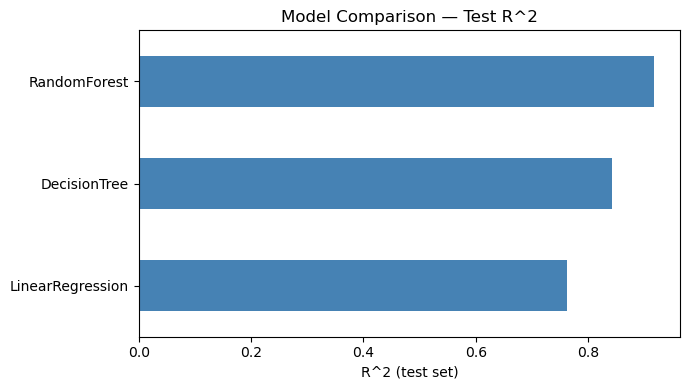

'\nBetter than decision tree due to bagging and averaging of \nmultiple decision tree reducing varaiance and overfitting\n\n'

In [8]:
# R^2 comparison chart — linear baseline value hardcoded from 03_baseline_model.ipynb
baseline_r2 = 0.7618
comparison = pd.Series({'LinearRegression': baseline_r2,
                        'DecisionTree': results['DecisionTree']['r2'],
                        'RandomForest': results['RandomForest']['r2']}).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
comparison.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('R^2 (test set)')
ax.set_title('Model Comparison — Test R^2')
plt.tight_layout()
plt.show()

"""
Better than decision tree due to bagging and averaging of 
multiple decision tree reducing varaiance and overfitting

"""

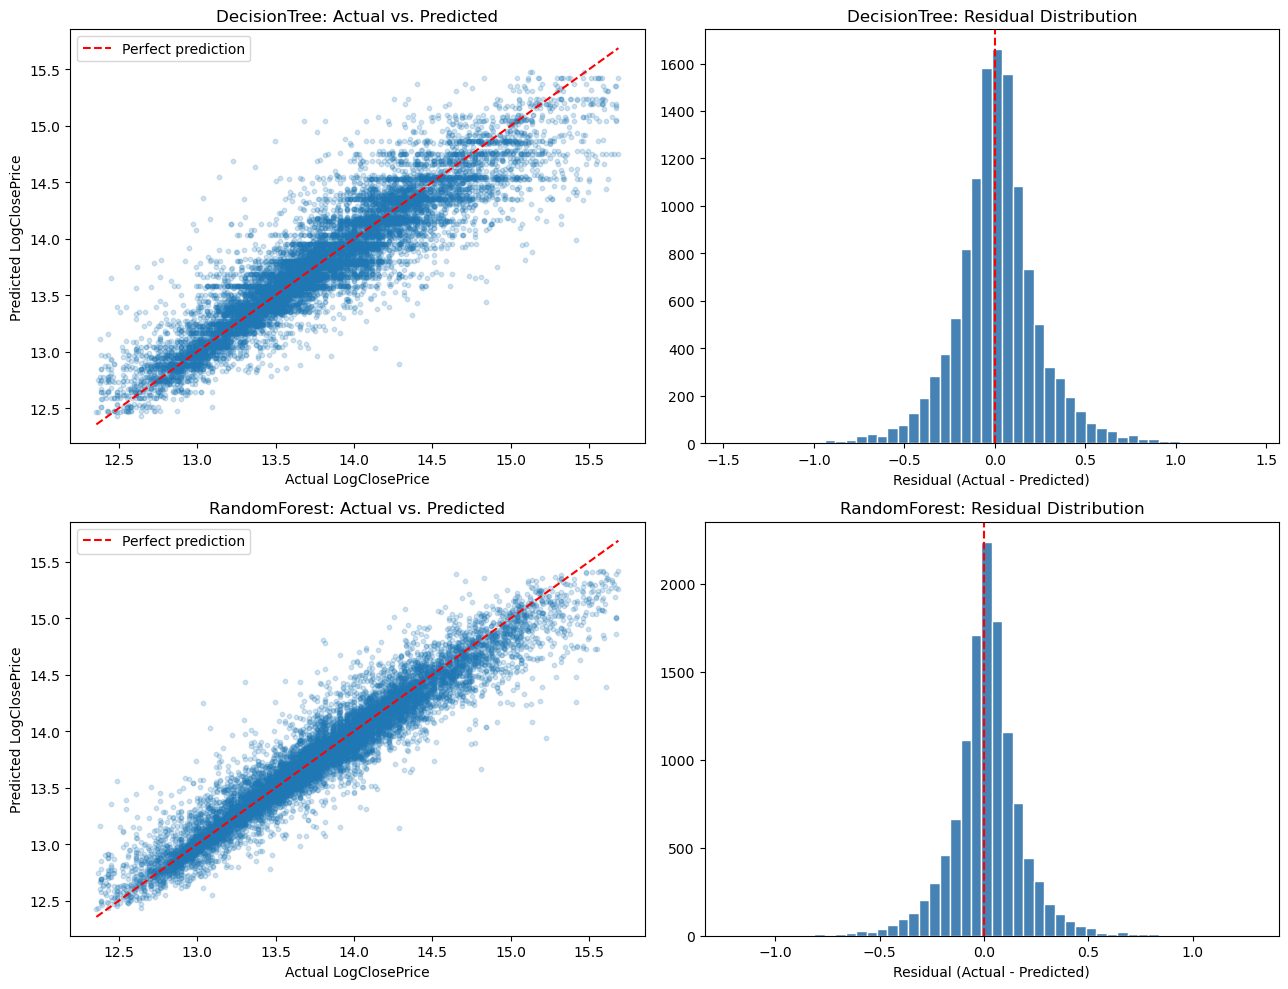

In [9]:
# Post-model diagnostics — actual vs. predicted and residual distribution, per model
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (name, res) in enumerate(results.items()):
    preds = res['pipeline'].predict(X_test)
    residuals = y_test - preds

    ax_scatter = axes[row, 0]
    ax_scatter.scatter(y_test, preds, alpha=0.2, s=10)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax_scatter.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
    ax_scatter.set_xlabel('Actual LogClosePrice')
    ax_scatter.set_ylabel('Predicted LogClosePrice')
    ax_scatter.set_title(f'{name}: Actual vs. Predicted')
    ax_scatter.legend()

    ax_hist = axes[row, 1]
    ax_hist.hist(residuals, bins=50, color='steelblue', edgecolor='white')
    ax_hist.axvline(0, color='red', linestyle='--')
    ax_hist.set_xlabel('Residual (Actual - Predicted)')
    ax_hist.set_title(f'{name}: Residual Distribution')

plt.tight_layout()
plt.show()

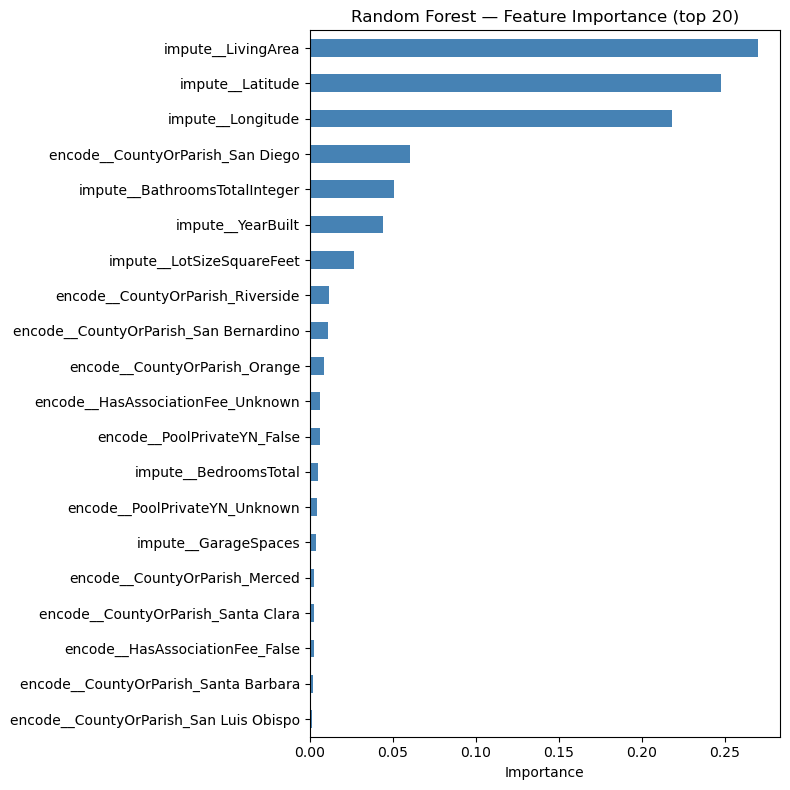

In [10]:
# Feature importance — Random Forest
feature_names = results['RandomForest']['pipeline'].named_steps['preprocessor'].get_feature_names_out()
importances = results['RandomForest']['pipeline'].named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
feat_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Feature Importance (top 20)')
plt.tight_layout()
plt.show()

### Feature Engineering — bed/bath ratio, property age, school district

Adds three engineered features to the original feature set and retrains
DecisionTree/RandomForest on the expanded set, so we can compare against
the original (tuned) results above.

In [11]:
# Bed/bath ratio, property age, and seasonality
CRMLSSold_cleaned['BedBathRatio'] = CRMLSSold_cleaned['BedroomsTotal'] / CRMLSSold_cleaned['BathroomsTotalInteger'].replace(0, np.nan)
CRMLSSold_cleaned['PropertyAge'] = CRMLSSold_cleaned['CloseDate'].dt.year - CRMLSSold_cleaned['YearBuilt']

# Seasonality — one-hot encoded close month (Jan-Dec) so each month gets its own
# coefficient/split instead of assuming a smooth sinusoidal pattern
CRMLSSold_cleaned['CloseMonthName'] = CRMLSSold_cleaned['CloseDate'].dt.strftime('%B')

# School district join
import geopandas as gpd

districts = gpd.read_file('../data/ca_school_districts.geojson')[['DistrictName', 'geometry']]

listings = gpd.GeoDataFrame(
    CRMLSSold_cleaned,
    geometry=gpd.points_from_xy(CRMLSSold_cleaned['Longitude'], CRMLSSold_cleaned['Latitude']),
    crs='EPSG:4326'
)

listings = gpd.sjoin(listings, districts, how='left', predicate='within')
listings = listings.drop(columns=['geometry', 'index_right'])

n_unmatched = listings['DistrictName'].isna().sum()
print(f"Unmatched to a district: {n_unmatched:,} ({n_unmatched / len(listings):.2%})")

# only 5 rows were missing so dropped
listings = listings.dropna(subset=['DistrictName'])

CRMLSSold_cleaned = pd.DataFrame(listings)
print(f"Unique districts: {CRMLSSold_cleaned['DistrictName'].nunique():,}")

Unmatched to a district: 5 (0.01%)
Unique districts: 675


In [12]:
# New feature set: original 15 features + BedBathRatio, PropertyAge, CloseMonthName, DistrictName
new_feature_cols = feature_cols + ['BedBathRatio', 'PropertyAge', 'CloseMonthName', 'DistrictName']
new_numeric_cols = numeric_cols + ['BedBathRatio', 'PropertyAge']

# DistrictName gets min_frequency bucketing so the ~900 sparsely-populated districts
# collapse into a single "infrequent" column instead of each getting its own
# thinly-populated one-hot column
new_preprocessor = ColumnTransformer([
    ('impute', SimpleImputer(strategy='median'), new_numeric_cols),
    ('encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols + ['CloseMonthName']),
    ('encode_district', OneHotEncoder(handle_unknown='ignore', min_frequency=50), ['DistrictName']),
])

X_train_new, y_train_new, X_test_new, y_test_new = make_train_test_split(
    CRMLSSold_cleaned, new_feature_cols, training_months=None
)

# Reuse the best hyperparameters found by GridSearchCV on the original feature set,
# so the comparison isolates the effect of the new features rather than re-tuning noise
new_results = {}
for name, model_class in model_classes.items():
    best_params = {k.replace('model__', ''): v for k, v in tuned_results[name]['best_params'].items()}
    pipeline = Pipeline([
        ('preprocessor', new_preprocessor),
        ('model', model_class(random_state=42, **best_params))
    ])
    pipeline.fit(X_train_new, y_train_new)

    train_preds = pipeline.predict(X_train_new)
    train_r2 = r2_score(y_train_new, train_preds)
    train_rmse = mean_squared_error(y_train_new, train_preds) ** 0.5

    preds = pipeline.predict(X_test_new)
    r2 = r2_score(y_test_new, preds)
    rmse = mean_squared_error(y_test_new, preds) ** 0.5

    new_results[name] = {
        'pipeline': pipeline,
        'train_r2': train_r2, 'train_rmse': train_rmse,
        'r2': r2, 'rmse': rmse,
    }
    print(f"{name}  (params: {best_params})")
    print(f"  Train R^2:              {train_r2:.4f}")
    print(f"  Train RMSE (log price): {train_rmse:.4f}")
    print(f"  Test R^2:               {r2:.4f}")
    print(f"  Test RMSE (log price):  {rmse:.4f}")
    print(f"  R^2 gap (train - test): {train_r2 - r2:.4f}\n")

Test month:  2026-06
Train range: 2025-11 to 2026-05  (7 months)
X_train: (83711, 19)  |  X_test: (15172, 19)
DecisionTree  (params: {'max_depth': 12, 'min_samples_leaf': 10})
  Train R^2:              0.8560
  Train RMSE (log price): 0.2295
  Test R^2:               0.8336
  Test RMSE (log price):  0.2492
  R^2 gap (train - test): 0.0224

RandomForest  (params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200})
  Train R^2:              0.9916
  Train RMSE (log price): 0.0553
  Test R^2:               0.9177
  Test RMSE (log price):  0.1753
  R^2 gap (train - test): 0.0740



In [13]:
# Old vs. new feature set — side-by-side comparison for both models
rows = {}
for name in model_classes:
    rows[(name, 'Old features')] = {
        'Test R^2': tuned_results[name]['r2'],
        'Test RMSE (log price)': tuned_results[name]['rmse'],
        'Train R^2': tuned_results[name]['train_r2'],
        'R^2 Gap (train - test)': tuned_results[name]['train_r2'] - tuned_results[name]['r2'],
    }
    rows[(name, 'New features')] = {
        'Test R^2': new_results[name]['r2'],
        'Test RMSE (log price)': new_results[name]['rmse'],
        'Train R^2': new_results[name]['train_r2'],
        'R^2 Gap (train - test)': new_results[name]['train_r2'] - new_results[name]['r2'],
    }

comparison_table = pd.DataFrame(rows).T.sort_index()
comparison_table.round(4)

Test R^2  Test RMSE (log price)  Train R^2  \
DecisionTree New features    0.8336                 0.2492     0.8560   
             Old features    0.8431                 0.2402     0.8715   
RandomForest New features    0.9177                 0.1753     0.9916   
             Old features    0.9178                 0.1739     0.9885   

                           R^2 Gap (train - test)  
DecisionTree New features                  0.0224  
             Old features                  0.0284  
RandomForest New features                  0.0740  
             Old features                  0.0706

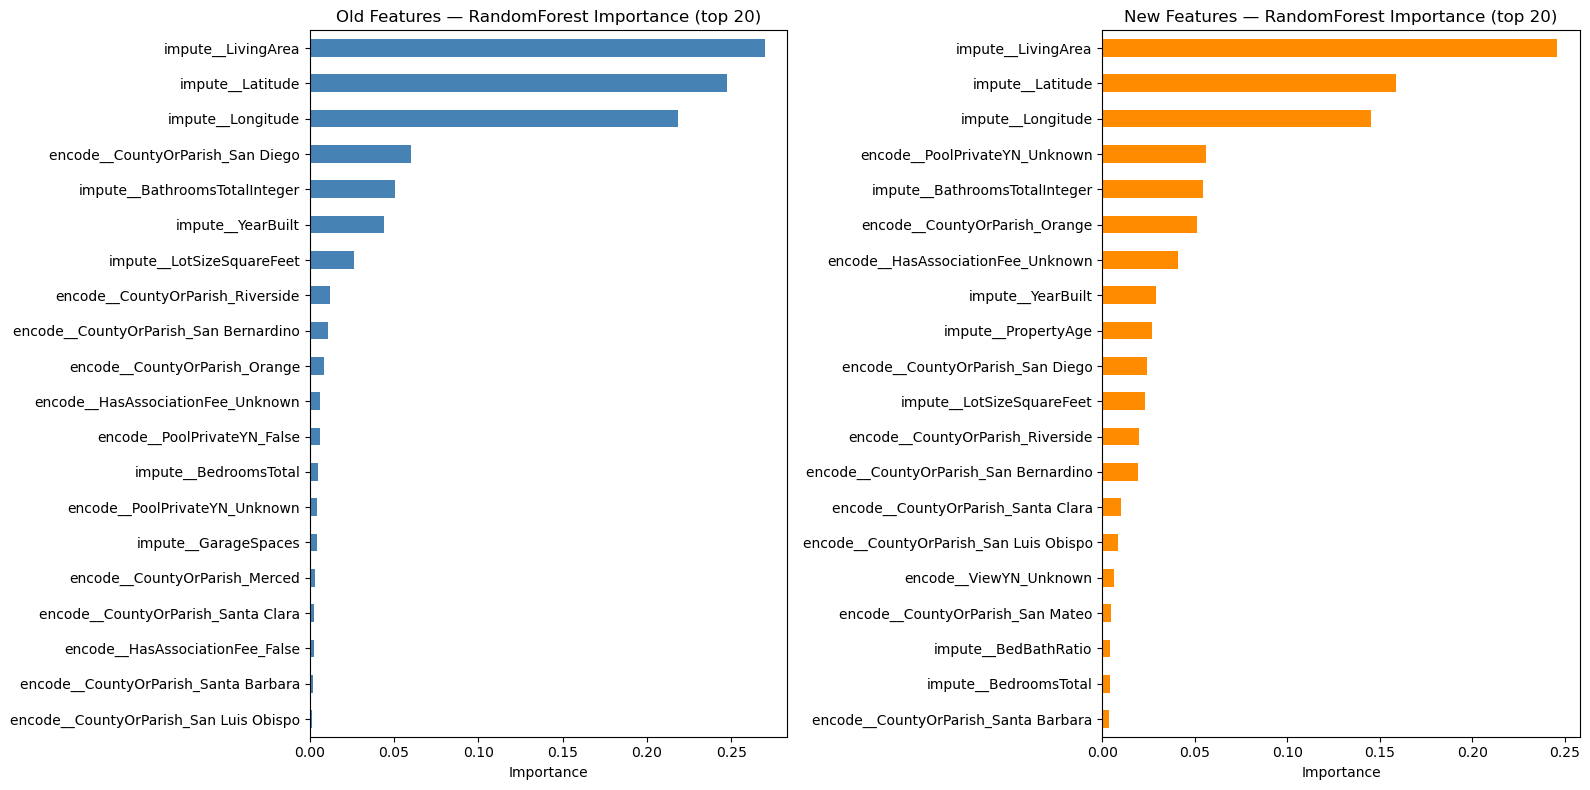

In [14]:
# Feature importance — old vs. new feature set, Random Forest
old_feature_names = tuned_results['RandomForest']['pipeline'].named_steps['preprocessor'].get_feature_names_out()
old_importances = tuned_results['RandomForest']['pipeline'].named_steps['model'].feature_importances_
old_feat_imp = pd.Series(old_importances, index=old_feature_names).sort_values(ascending=True)

new_feature_names = new_results['RandomForest']['pipeline'].named_steps['preprocessor'].get_feature_names_out()
new_importances = new_results['RandomForest']['pipeline'].named_steps['model'].feature_importances_
new_feat_imp = pd.Series(new_importances, index=new_feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

old_feat_imp.tail(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Old Features — RandomForest Importance (top 20)')

new_feat_imp.tail(20).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Importance')
axes[1].set_title('New Features — RandomForest Importance (top 20)')

plt.tight_layout()
plt.show()

### Why the new features should be removed

The old-vs-new comparison and the feature-importance plot above both point the
same direction: the four engineered features didn't earn their place, and two
of them are actively making the model worse.

- **`DistrictName` should go.** It doesn't appear anywhere in the new
  feature-importance top 20 — not even the bucketed "infrequent" column. It
  added ~150+ one-hot columns (even after `min_frequency` bucketing) with zero
  visible benefit, while diluting the importance mass of the features that
  actually matter: `LivingArea` (0.27 → 0.25), `Latitude` (0.25 → 0.16), and
  `Longitude` (0.22 → 0.145) all dropped, not because they became less
  predictive, but because their share of total importance got split across
  many more low-value columns. For RandomForest, it also pushed the R^2 gap up
  (0.0706 → 0.0740) — Train R^2 jumped (0.9885 → 0.9916) while Test R^2 stayed
  flat, the textbook signature of extra columns letting the model fit noise
  without generalizing any better. `DistrictName` is also largely redundant
  with `Latitude`/`Longitude`/`CountyOrParish`, which already encode the same
  location signal.

- **`CloseMonthName` should go.** Same story — no month column cracked the top
  20. With only 7 months in the training window, one-hot encoding gives most
  months only a handful of examples, not enough for the model to learn a
  reliable per-month effect.

- **`BedBathRatio` should go.** It lands dead last in the new importance
  ranking, barely above zero. It's a simple ratio of `BedroomsTotal` and
  `BathroomsTotalInteger`, both of which the tree already sees directly — a
  tree can already approximate ratio-like splits by combining raw features
  across nodes, so precomputing the ratio mostly adds a redundant, lower-value
  column rather than new capability.

- **`PropertyAge` is the only one worth a second look.** It shows up in the
  list, though still ranked below the raw `YearBuilt` it's derived from
  (`PropertyAge = CloseYear - YearBuilt`). It's not clearly harmful, but it's
  not clearly earning its keep either — worth testing on its own, isolated
  from the other three, before deciding to keep it.

**Net result:** Test R^2 went down for DecisionTree (0.8431 → 0.8336) and was
flat for RandomForest (0.9178 → 0.9177), while the RandomForest overfitting
gap grew. None of that justifies keeping the school-district join or the
one-hot month feature in the final model.